# PyGaborSTM Benchmark

Properly-synchronized timing of CPU vs GPU paths.

GPU work is asynchronous by default — `time.perf_counter()` only sees when Python submitted work, not when CUDA finished. To get honest measurements we wrap every timed block with `cp.cuda.Stream.null.synchronize()` before and after, and take the median across many iterations to reduce jitter.

In [1]:
import time, statistics
import cupy as cp
print(f"CuPy {cp.__version__}, CUDA available: {cp.cuda.is_available()}, Device: {cp.cuda.Device(0).id}")

CuPy 14.0.1, CUDA available: True, Device: 0


In [2]:
N_FILTERS = 256
FRMLEN_MS = 8.0
RIPPLE_F_MIN = 1000 / (2 ** (5.3 / 2))
RIPPLE_OCTAVES = 5.3
RESOLUTION = "low"
SR = 16000
DURATION = 5.0

In [3]:
import sys, re
sys.path.insert(0, "..")

import numpy as np
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import pygaborstm as stm

shared_kwargs = dict(
    resolution=RESOLUTION,
    n_filters=N_FILTERS,
    frmlen_ms=FRMLEN_MS,
    f_min=RIPPLE_F_MIN,
    octaves=RIPPLE_OCTAVES,
)
model_cpu = stm.PyGaborSTM(stm.Config(use_gpu=False, **shared_kwargs))
model_gpu = stm.PyGaborSTM(stm.Config(use_gpu=True, **shared_kwargs))

print(f"PyGaborSTM {stm.__version__}")
print(f"Resolution: {RESOLUTION}, Filters: {N_FILTERS}, Frame: {FRMLEN_MS}ms")

/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


PyGaborSTM 0.1.0
Resolution: low, Filters: 256, Frame: 8.0ms


In [4]:
DATA_DIR = Path("./data")
RIPPLE_DIR = DATA_DIR / "mvripfft"

def load_audio(filepath):
    audio, _ = librosa.load(filepath, sr=SR)
    max_samples = int(DURATION * SR)
    return audio[:max_samples] if len(audio) > max_samples else audio

def parse_ripple_filename(filename):
    match = re.search(r'R(-?\d+\.?\d*)_S(\d+\.?\d*)', filename.stem)
    return float(match.group(1)), float(match.group(2))

valid_rates = set(model_cpu.config.rates)
valid_scales = set(model_cpu.config.scales)

audios = []
for filepath in sorted(RIPPLE_DIR.glob("ripple_*.wav")):
    rate, scale = parse_ripple_filename(filepath)
    if rate in valid_rates and scale in valid_scales:
        audios.append(load_audio(filepath))

print(f"Loaded {len(audios)} files, {audios[0].shape[0]/SR:.1f}s each")

Loaded 60 files, 5.0s each


## Benchmark helper

Takes the median of `n_iters` runs. For GPU functions, syncs before and after each run so the clock captures real compute time. Defaults are conservative — `n_iters=20`, `n_warmup=2` — and can be dropped to `n_iters=1, n_warmup=0` for batch runs where the batch itself contains enough work to be a stable sample.

In [5]:
def benchmark(fn, *, gpu=False, n_warmup=2, n_iters=20):
    """Time fn over n_iters runs; return median seconds.

    For GPU code, syncs before and after each timed iteration so
    time.perf_counter() captures real GPU work, not just dispatch.
    """
    for _ in range(n_warmup):
        fn()
    if gpu:
        cp.cuda.Stream.null.synchronize()

    times = []
    for _ in range(n_iters):
        if gpu:
            cp.cuda.Stream.null.synchronize()
        t0 = time.perf_counter()
        fn()
        if gpu:
            cp.cuda.Stream.null.synchronize()
        times.append(time.perf_counter() - t0)

    return statistics.median(times)

## Global warmup

Pre-builds every cache (gammatone SOS, Gabor kernel FFT, FFT plans) and triggers CUDA context initialization. Without this, the first GPU benchmark would absorb hundreds of ms of one-time setup cost.

In [6]:
# Trigger CUDA context init explicitly
_ = cp.arange(1).sum()
cp.cuda.Stream.null.synchronize()

# Build all caches by running each path once
_ = model_cpu.compute(audios[0])
_ = model_cpu.spectrogram(audios[0])
_ = model_gpu.compute(audios[0])
_ = model_gpu.spectrogram(audios[0])
_ = model_gpu.compute_device(audios[0])
cp.cuda.Stream.null.synchronize()
print("Warmup complete")

Warmup complete


## Single file benchmark

Median of 20 iterations per path. Same audio across all paths so we're comparing implementations, not workloads.

In [7]:
audio = audios[0]

results_single = {
    'CPU separate':         benchmark(lambda: model_cpu.rsf(model_cpu.spectrogram(audio)),  gpu=False),
    'CPU compute()':        benchmark(lambda: model_cpu.compute(audio),                     gpu=False),
    'GPU separate':         benchmark(lambda: model_gpu.rsf(model_gpu.spectrogram(audio)),  gpu=True),
    'GPU compute()':        benchmark(lambda: model_gpu.compute(audio),                     gpu=True),
    'GPU compute_device()': benchmark(lambda: model_gpu.compute_device(audio),              gpu=True),
}

cpu_baseline = results_single['CPU separate']
print(f"Single file (median of 20 iterations):\n")
for name, t in results_single.items():
    speedup = cpu_baseline / t
    print(f"  {name:<25s} {t*1000:7.2f} ms  ({speedup:5.1f}x vs CPU separate)")

Single file (median of 20 iterations):

  CPU separate              2255.15 ms  (  1.0x vs CPU separate)
  CPU compute()             2273.00 ms  (  1.0x vs CPU separate)
  GPU separate                78.34 ms  ( 28.8x vs CPU separate)
  GPU compute()              103.35 ms  ( 21.8x vs CPU separate)
  GPU compute_device()        94.74 ms  ( 23.8x vs CPU separate)


## Batch benchmark

One full batch per path. `n_iters=1` because the batch itself is 60 samples worth of work — already a stable measurement. Still wrapped in sync calls so async dispatch doesn't undercount.

In [8]:
def make_batch(work_per_audio):
    def run():
        for audio in audios:
            work_per_audio(audio)
    return run

results_batch = {
    'CPU separate':         benchmark(make_batch(lambda a: model_cpu.rsf(model_cpu.spectrogram(a))), gpu=False, n_warmup=0, n_iters=1),
    'CPU compute()':        benchmark(make_batch(lambda a: model_cpu.compute(a)),                    gpu=False, n_warmup=0, n_iters=1),
    'GPU separate':         benchmark(make_batch(lambda a: model_gpu.rsf(model_gpu.spectrogram(a))), gpu=True,  n_warmup=0, n_iters=1),
    'GPU compute()':        benchmark(make_batch(lambda a: model_gpu.compute(a)),                    gpu=True,  n_warmup=0, n_iters=1),
    'GPU compute_device()': benchmark(make_batch(lambda a: model_gpu.compute_device(a)),             gpu=True,  n_warmup=0, n_iters=1),
}

cpu_baseline = results_batch['CPU separate']
print(f"Batch ({len(audios)} files):\n")
for name, t in results_batch.items():
    speedup = cpu_baseline / t
    per_file_ms = t / len(audios) * 1000
    print(f"  {name:<25s} {t:7.2f}s  ({per_file_ms:6.1f} ms/file, {speedup:5.1f}x vs CPU)")

Batch (60 files):

  CPU separate               132.21s  (2203.5 ms/file,   1.0x vs CPU)
  CPU compute()              131.37s  (2189.4 ms/file,   1.0x vs CPU)
  GPU separate                 4.52s  (  75.3 ms/file,  29.3x vs CPU)
  GPU compute()                5.85s  (  97.5 ms/file,  22.6x vs CPU)
  GPU compute_device()         5.43s  (  90.5 ms/file,  24.3x vs CPU)


## y1 stage: cupyx loop vs f64 kernel vs f32 kernel

Isolates the gammatone filterbank stage so we can see what the custom kernel actually buys us, separate from the rest of the pipeline.

In [9]:
from cupyx.scipy.signal import sosfilt as cu_sosfilt
from pygaborstm.gammatone_kernel import batched_sosfilt

sos_d = model_gpu._spec_model._sos_device           # float64
sos_d_f32 = sos_d.astype(cp.float32)
x_d = cp.asarray(audios[0], dtype=cp.float32)

t_loop = benchmark(
    lambda: cp.stack([2.0 * cu_sosfilt(sos_d[c], x_d) for c in range(sos_d.shape[0])]),
    gpu=True,
)
t_f64 = benchmark(
    lambda: batched_sosfilt(sos_d, x_d, gain=2.0, precision='float64'),
    gpu=True,
)
t_f32 = benchmark(
    lambda: batched_sosfilt(sos_d_f32, x_d, gain=2.0, precision='float32'),
    gpu=True,
)

print(f"y1 stage, {sos_d.shape[0]} channels × {x_d.shape[0]} samples (median of 20 iters):")
print(f"  cupyx loop:    {t_loop*1000:7.2f} ms")
print(f"  f64 kernel:    {t_f64*1000:7.2f} ms   {t_loop/t_f64:5.1f}x vs loop")
print(f"  f32 kernel:    {t_f32*1000:7.2f} ms   {t_loop/t_f32:5.1f}x vs loop")
print(f"  f32 vs f64 kernel speedup: {t_f64/t_f32:.1f}x")

y1 stage, 256 channels × 80000 samples (median of 20 iters):
  cupyx loop:      76.11 ms
  f64 kernel:      44.05 ms     1.7x vs loop
  f32 kernel:       9.37 ms     8.1x vs loop
  f32 vs f64 kernel speedup: 4.7x


## Full pipeline with the kernel forcibly disabled

Sanity check: how much of the GPU pipeline speedup is the batched-SOS kernel? Build a second GPU model with the fast path disabled, compare end-to-end.

In [10]:
model_gpu_loop = stm.PyGaborSTM(stm.Config(use_gpu=True, **shared_kwargs))
model_gpu_loop._spec_model._batched_sosfilt = None  # force fallback path

_ = model_gpu_loop.compute(audios[0])  # warmup
cp.cuda.Stream.null.synchronize()

gpu_loop_time = benchmark(
    make_batch(lambda a: model_gpu_loop.compute(a)),
    gpu=True, n_warmup=0, n_iters=1,
)
gpu_kernel_time = results_batch['GPU compute()']

print(f"Full pipeline, {len(audios)} files:")
print(f"  GPU (sosfilt loop):     {gpu_loop_time:7.2f}s  ({gpu_loop_time/len(audios)*1000:6.1f} ms/file)")
print(f"  GPU (batched kernel):   {gpu_kernel_time:7.2f}s  ({gpu_kernel_time/len(audios)*1000:6.1f} ms/file)")
print(f"  end-to-end speedup:     {gpu_loop_time/gpu_kernel_time:.2f}x")

Full pipeline, 60 files:
  GPU (sosfilt loop):       10.26s  ( 171.0 ms/file)
  GPU (batched kernel):      5.85s  (  97.5 ms/file)
  end-to-end speedup:     1.75x


In [11]:
# Confirm the fast path is actually wired up
spec = model_gpu._spec_model
print(f"float_dtype:         {spec.float_dtype}")
print(f"_batched_sosfilt:    {spec._batched_sosfilt}")
print(f"_sos_device_f32:     {(spec._sos_device_f32.shape, spec._sos_device_f32.dtype) if spec._sos_device_f32 is not None else None}")

float_dtype:         <class 'numpy.float32'>
_batched_sosfilt:    <function batched_sosfilt at 0x7f75d21b7880>
_sos_device_f32:     ((256, 4, 6), dtype('float32'))


## Stage breakdown (GPU)

Where is the remaining GPU time going? Split spectrogram vs RSF.

In [12]:
cp.cuda.Stream.null.synchronize()
t0 = time.perf_counter()
specs = [model_gpu.spectrogram(audio) for audio in audios]
cp.cuda.Stream.null.synchronize()
gpu_spec_time = time.perf_counter() - t0

cp.cuda.Stream.null.synchronize()
t0 = time.perf_counter()
rsfs = [model_gpu.rsf(spec) for spec in specs]
cp.cuda.Stream.null.synchronize()
gpu_rsf_time = time.perf_counter() - t0

total = gpu_spec_time + gpu_rsf_time
print(f"GPU spectrogram: {gpu_spec_time:5.2f}s ({gpu_spec_time/len(audios)*1000:5.1f} ms/file, {gpu_spec_time/total*100:4.1f}% of total)")
print(f"GPU RSF:         {gpu_rsf_time:5.2f}s ({gpu_rsf_time/len(audios)*1000:5.1f} ms/file, {gpu_rsf_time/total*100:4.1f}% of total)")

GPU spectrogram:  3.18s ( 53.1 ms/file, 64.3% of total)
GPU RSF:          1.76s ( 29.4 ms/file, 35.7% of total)


## VRAM usage

In [13]:
mempool = cp.get_default_memory_pool()
print(f"GPU memory used:  {mempool.used_bytes() / 1e9:.2f} GB")
print(f"GPU memory pool:  {mempool.total_bytes() / 1e9:.2f} GB")

GPU memory used:  1.28 GB
GPU memory pool:  9.37 GB


## Results

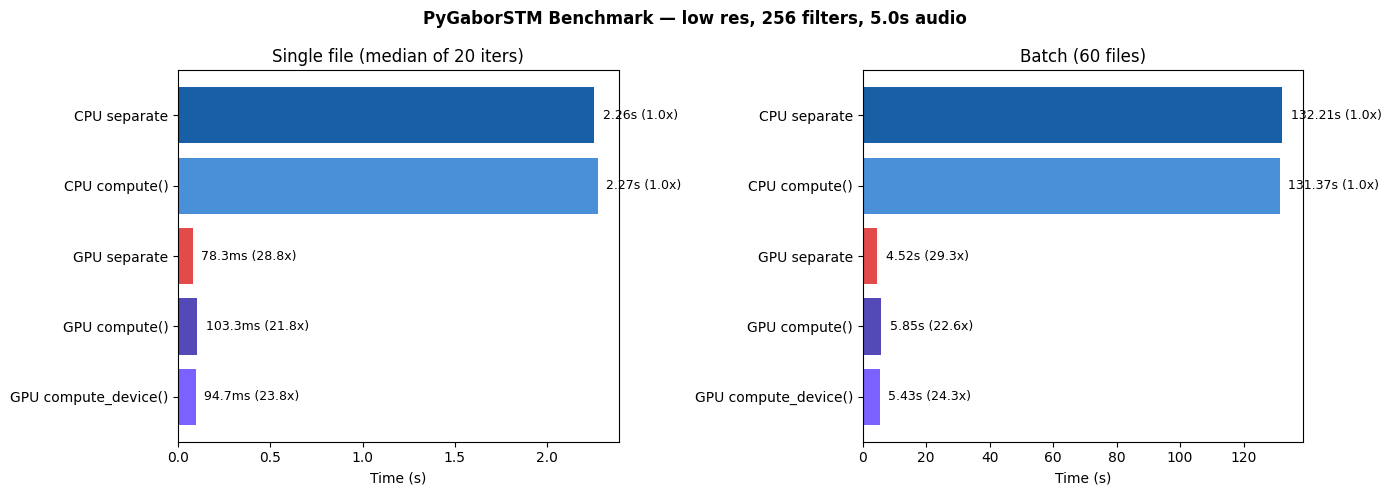

Saved benchmark_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#185FA5', '#4A90D9', '#E24B4A', '#534AB7', '#7B61FF']

for ax, title, results in [
    (axes[0], 'Single file (median of 20 iters)', results_single),
    (axes[1], f'Batch ({len(audios)} files)', results_batch),
]:
    names = list(results.keys())
    times = list(results.values())
    bars = ax.barh(names, times, color=colors[:len(names)])
    ax.set_xlabel('Time (s)')
    ax.set_title(title)
    ax.invert_yaxis()

    cpu_baseline = results['CPU separate']
    for bar, t in zip(bars, times):
        speedup = cpu_baseline / t
        label = f'{t*1000:.1f}ms' if t < 1 else f'{t:.2f}s'
        label += f' ({speedup:.1f}x)'
        ax.text(bar.get_width() + max(times) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', fontsize=9)

fig.suptitle(
    f'PyGaborSTM Benchmark — {RESOLUTION} res, {N_FILTERS} filters, {DURATION}s audio',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_results.png')

**NOTE:** 
chained `compute_device` runs ~15ms slower than calling `spectrogram()` -> `rsf()` separately on single files. Cause appears to be device-side allocation pattern interacting with cuFFT — gabor stage runs *~17ms* when spec arrives via host-DMA upload but *~41ms* when spec arrives from a prior device kernel. Batch throughput is unaffected. Investigate with **nsys** if it ever matters.